# 06 · Decoder Anatomy: Where the KV Cache Goes

**Hardware**: 🟢 CPU for everything structural. No checkpoint download — the config comparison reads released JSON, and the measurements use a miniature model.

## What you will do

1. Read the real attention schedule off all four released sizes
2. Reimplement `sliding_window_mask_function` and check it against the library
3. See a decoder that has **fewer cache entries than layers**, because KV-shared layers hold nothing
4. Watch sliding layers cap their cache at the window while global layers grow with the sequence
5. Confirm the coupling: the layers that give up KV projections are the ones with a double-wide MLP
6. Quantify what each trick saves

In [1]:
%pip install -q "transformers>=5.14" torch huggingface_hub matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import torch
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

from transformers import Gemma4TextConfig, Gemma4ForCausalLM
from transformers.models.gemma4.modeling_gemma4 import sliding_window_mask_function

torch.manual_seed(0)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. The schedule, from the released checkpoints

In [3]:
sizes = ["E2B", "31B", "26B-A4B"]
raw = {s: json.load(open(hf_hub_download(f"google/gemma-4-{s}-it", "config.json"))) for s in sizes}

for s in sizes:
    t = raw[s]["text_config"]
    lt = t["layer_types"]
    full = [i for i, x in enumerate(lt) if x == "full_attention"]
    gap = full[1] - full[0] if len(full) > 1 else None
    print(f"{s:>9}: {len(lt):2d} layers | window {t['sliding_window']:5d} | "
          f"{len(full):2d} global ({100*len(full)/len(lt):.0f}%) every {gap} | "
          f"kv_heads {t['num_key_value_heads']:2d} | shared {t['num_kv_shared_layers']:2d} | "
          f"k_eq_v {str(t['attention_k_eq_v'])}")
    print(f"{'':>11}global at {full}")

      E2B: 35 layers | window   512 |  7 global (20%) every 5 | kv_heads  1 | shared 20 | k_eq_v False
           global at [4, 9, 14, 19, 24, 29, 34]
      31B: 60 layers | window  1024 | 10 global (17%) every 6 | kv_heads 16 | shared  0 | k_eq_v True
           global at [5, 11, 17, 23, 29, 35, 41, 47, 53, 59]
  26B-A4B: 30 layers | window  1024 |  5 global (17%) every 6 | kv_heads  8 | shared  0 | k_eq_v True
           global at [5, 11, 17, 23, 29]


Five sixths of every forward pass sees only a local window. That is the single biggest reason 128K–256K context is affordable.

Note the two families make **opposite** bets: E2B goes MQA (`num_key_value_heads=1`) plus 20 of 35 layers sharing KV; the large models keep 16 or 8 KV heads but collapse K and V into one projection on global layers.

## 2. The window as a predicate

The library never builds a `[seq, seq]` tensor unless a backend demands one — the window is a function of `(q_idx, kv_idx)`.

In [4]:
def my_sliding_window_mask_function(sliding_window):
    def inner_mask(batch_idx, head_idx, q_idx, kv_idx):
        left_window_size, right_window_size = sliding_window
        dist = q_idx - kv_idx
        left_mask = (dist >= 0) & (dist < left_window_size)
        right_mask = (dist < 0) & (-dist < right_window_size)
        return left_mask | right_mask
    return inner_mask


for window in [(8, 0), (4, 4)]:
    lib = sliding_window_mask_function(window)
    mine = my_sliding_window_mask_function(window)
    n = 14
    for q in range(n):
        for k in range(n):
            assert bool(lib(0, 0, q, k)) == bool(mine(0, 0, q, k)), (window, q, k)
    print(f"window={window} matches the library ✓")
    for q in range(n):
        print("   " + "".join("#" if lib(0, 0, q, k) else "." for k in range(n)))
    print()

window=(8, 0) matches the library ✓
   #.............
   ##............
   ###...........
   ####..........
   #####.........
   ######........
   #######.......
   ########......
   .########.....
   ..########....
   ...########...
   ....########..
   .....########.
   ......########

window=(4, 4) matches the library ✓
   ####..........
   #####.........
   ######........
   #######.......
   .#######......
   ..#######.....
   ...#######....
   ....#######...
   .....#######..
   ......#######.
   .......#######
   ........######
   .........#####
   ..........####



The second case is the symmetric form — a right window. Nothing in the *decoder* uses it, but the audio tower does ([chapter 05](../../05-audio-and-video/index.md)) and so does bidirectional vision attention ([chapter 08](../../08-fusion-and-masks/index.md)). One predicate, three jobs.

## 3. A miniature decoder

In [5]:
def make_decoder(**overrides):
    cfg = dict(
        vocab_size=512, hidden_size=64, intermediate_size=128,
        num_hidden_layers=12, num_attention_heads=4, num_key_value_heads=1,
        head_dim=16, global_head_dim=32, sliding_window=8,
        hidden_size_per_layer_input=0, num_kv_shared_layers=0,
    )
    cfg.update(overrides)
    config = Gemma4TextConfig(**cfg)
    return config, Gemma4ForCausalLM(config).eval()


config, model = make_decoder(num_kv_shared_layers=4, use_double_wide_mlp=True)

print(f"{'layer':>5} | {'type':<18} | {'head_dim':>8} | {'kv_shared':>9} | "
      f"{'mlp width':>9} | {'donor':>5}")
print("-" * 70)
for i, layer in enumerate(model.model.layers):
    a = layer.self_attn
    print(f"{i:5d} | {a.layer_type:<18} | {a.head_dim:8d} | {str(a.is_kv_shared_layer):>9} | "
          f"{layer.mlp.intermediate_size:9d} | {str(a.store_full_length_kv):>5}")

layer | type               | head_dim | kv_shared | mlp width | donor
----------------------------------------------------------------------
    0 | sliding_attention  |       16 |     False |       128 | False
    1 | sliding_attention  |       16 |     False |       128 | False
    2 | sliding_attention  |       16 |     False |       128 | False
    3 | sliding_attention  |       16 |     False |       128 | False
    4 | sliding_attention  |       16 |     False |       128 | False
    5 | full_attention     |       32 |     False |       128 |  True
    6 | sliding_attention  |       16 |     False |       128 | False
    7 | sliding_attention  |       16 |     False |       128 |  True
    8 | sliding_attention  |       16 |      True |       256 | False
    9 | sliding_attention  |       16 |      True |       256 | False
   10 | sliding_attention  |       16 |      True |       256 | False
   11 | full_attention     |       32 |      True |       256 | False


Three things to read off:

- **Global layers have bigger heads** (32 vs 16 here; 512 vs 256 in the real checkpoints). Rarer, but individually more expressive.
- **MLP width doubles exactly where KV sharing starts.** `Gemma4TextMLP.__init__` gates `use_double_wide_mlp` on `is_kv_shared_layer` — one decision, not two flags: stop paying for attention in the upper layers, spend it on feed-forward instead.
- **Two donors**, one per layer type. A sliding layer's keys are rotated with θ=10,000 and a global layer's with θ=1,000,000, so they are not interchangeable.

## 4. The cache

Run a forward pass and look at what was actually kept.

In [6]:
ids = torch.randint(0, 500, (1, 64))
with torch.no_grad():
    out = model(input_ids=ids, use_cache=True)

cache = out.past_key_values
print(f"sequence length: {ids.shape[1]}")
print(f"model layers   : {config.num_hidden_layers}")
print(f"cache entries  : {len(cache.layers)}   <- fewer!\n")

for i, layer in enumerate(cache.layers):
    k = getattr(layer, "keys", None)
    print(f"  cache[{i}]  {type(layer).__name__:<26} keys={tuple(k.shape) if k is not None else None}")

sequence length: 64
model layers   : 12
cache entries  : 8   <- fewer!

  cache[0]  DynamicSlidingWindowLayer  keys=(1, 1, 7, 16)
  cache[1]  DynamicSlidingWindowLayer  keys=(1, 1, 7, 16)
  cache[2]  DynamicSlidingWindowLayer  keys=(1, 1, 7, 16)
  cache[3]  DynamicSlidingWindowLayer  keys=(1, 1, 7, 16)
  cache[4]  DynamicSlidingWindowLayer  keys=(1, 1, 7, 16)
  cache[5]  DynamicLayer               keys=(1, 1, 64, 32)
  cache[6]  DynamicSlidingWindowLayer  keys=(1, 1, 7, 16)
  cache[7]  DynamicSlidingWindowLayer  keys=(1, 1, 7, 16)


Everything in this chapter is in that printout.

1. **12 layers, 8 cache entries.** The 4 KV-shared layers store nothing — they read `shared_kv_states` instead, which is why `Gemma4CausalLMOutputWithPast` carries that field separately from `past_key_values`.
2. **Sliding layers cap at the window.** Their keys are 7 positions long for a 64-token sequence, and they use a different cache class (`DynamicSlidingWindowLayer`). Feed 64K tokens and they will still be 7.
3. **The global layer keeps all 64** — and at double the head dimension. This is the layer whose cost actually grows with context.

## 5. What it saves

[transformers] Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'full_attention', 'sliding_attention'}


 seq len |         no sharing |     4 of 12 shared |     6 of 12 shared |  all layers global
----------------------------------------------------------------------------------------------
      32 |              6,336 |              3,616 |              3,168 |             24,576
      64 |             10,432 |              5,664 |              5,216 |             49,152
     128 |             18,624 |              9,760 |              9,312 |             98,304
     256 |             35,008 |             17,952 |             17,504 |            196,608
     512 |             67,776 |             34,336 |             33,888 |            393,216
    1024 |            133,312 |             67,104 |             66,656 |            786,432


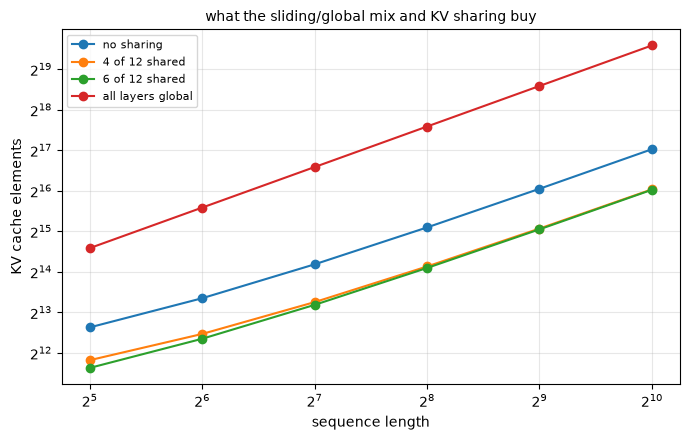

In [7]:
def cache_elements(model, seq_len):
    with torch.no_grad():
        out = model(input_ids=torch.randint(0, 500, (1, seq_len)), use_cache=True)
    total = 0
    for layer in out.past_key_values.layers:
        k = getattr(layer, "keys", None)
        if k is not None:
            total += k.numel() * 2          # keys + values
    return total


lengths = [32, 64, 128, 256, 512, 1024]
variants = {
    "no sharing":              make_decoder(num_kv_shared_layers=0)[1],
    "4 of 12 shared":          make_decoder(num_kv_shared_layers=4)[1],
    "6 of 12 shared":          make_decoder(num_kv_shared_layers=6)[1],
    "all layers global":       make_decoder(num_kv_shared_layers=0,
                                            layer_types=["full_attention"] * 12)[1],
}

results = {name: [cache_elements(m, n) for n in lengths] for name, m in variants.items()}

print(f"{'seq len':>8} | " + " | ".join(f"{k:>18}" for k in results))
print("-" * (10 + 21 * len(results)))
for i, n in enumerate(lengths):
    print(f"{n:8d} | " + " | ".join(f"{results[k][i]:18,}" for k in results))

fig, ax = plt.subplots(figsize=(7, 4.5))
for name, vals in results.items():
    ax.plot(lengths, vals, marker="o", label=name)
ax.set_xscale("log", base=2); ax.set_yscale("log", base=2)
ax.set_xlabel("sequence length"); ax.set_ylabel("KV cache elements")
ax.set_title("what the sliding/global mix and KV sharing buy", fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

Why 6 and not 8? The sharing boundary sits at `num_hidden_layers - num_kv_shared_layers`, and at least one **unshared layer of each type** must remain to donate its keys and values. With global layers at 5 and 11, a boundary below 6 leaves no global donor and the first shared global layer raises `KeyError: 'full_attention'`. Six is the maximum here — try 8 and watch it fail.

The all-global line is the one to look at: it grows linearly with sequence length at every layer. The others flatten, because only the global layers keep growing — the sliding ones are pinned at their window.

## 6. QK-norm, and the missing `1/sqrt(d)`

In [8]:
attn = model.model.layers[0].self_attn
print("q_norm:", attn.q_norm)
print("k_norm:", attn.k_norm)
print("v_norm:", attn.v_norm, "  <- with_scale=False: no learnable parameter")
print("\nscaling:", attn.scaling)
print("\nThe customary 1/sqrt(head_dim) =", round(attn.head_dim ** -0.5, 4), "is gone.")
print("Normalising q and k already fixes their magnitudes, so the compensation is unnecessary.")

print("\nv_norm parameters:", sum(p.numel() for p in attn.v_norm.parameters()))
print("q_norm parameters:", sum(p.numel() for p in attn.q_norm.parameters()))

q_norm: Gemma4RMSNorm()
k_norm: Gemma4RMSNorm()
v_norm: Gemma4RMSNorm()   <- with_scale=False: no learnable parameter

scaling: 1.0

The customary 1/sqrt(head_dim) = 0.25 is gone.
Normalising q and k already fixes their magnitudes, so the compensation is unnecessary.

v_norm parameters: 0
q_norm parameters: 16


## 7. Two RoPEs, one model

In [9]:
rope = model.model.rotary_emb
for lt in sorted(set(config.layer_types)):
    inv = getattr(rope, f"{lt}_inv_freq")
    params = config.rope_parameters[lt]
    print(f"{lt:<18} theta={params['rope_theta']:>10,.0f}  type={params['rope_type']:<12} "
          f"inv_freq {tuple(inv.shape)}  range [{inv.min():.2e}, {inv.max():.2e}]")

print("\nA sliding layer's largest possible distance is the window, so theta=10,000 resolves it.")
print("A global layer must separate positions up to 262,144 apart, so it needs theta=1,000,000")
print("and rotates only a quarter of its (larger) head dimensions.")

full_attention     theta= 1,000,000  type=proportional inv_freq (16,)  range [0.00e+00, 1.00e+00]
sliding_attention  theta=    10,000  type=default      inv_freq (8,)  range [3.16e-04, 1.00e+00]

A sliding layer's largest possible distance is the window, so theta=10,000 resolves it.
A global layer must separate positions up to 262,144 apart, so it needs theta=1,000,000
and rotates only a quarter of its (larger) head dimensions.


## 8. Logit softcapping

softcapping: 30.0
logit range: [-0.639, 0.595]  (bounded by +/-30 by construction)


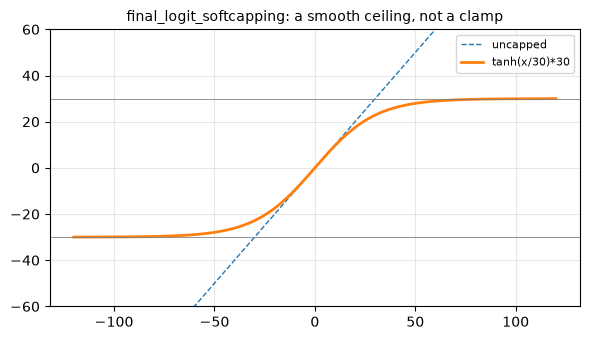

In [10]:
config_cap, model_cap = make_decoder(final_logit_softcapping=30.0)
with torch.no_grad():
    logits = model_cap(input_ids=ids).logits
print("softcapping:", config_cap.final_logit_softcapping)
print(f"logit range: [{logits.min():.3f}, {logits.max():.3f}]  (bounded by +/-30 by construction)")

x = torch.linspace(-120, 120, 400)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(x, x, "--", lw=1, label="uncapped")
ax.plot(x, torch.tanh(x / 30) * 30, lw=2, label="tanh(x/30)*30")
ax.axhline(30, color="grey", lw=.6); ax.axhline(-30, color="grey", lw=.6)
ax.set_ylim(-60, 60); ax.legend(fontsize=8); ax.grid(alpha=.3)
ax.set_title("final_logit_softcapping: a smooth ceiling, not a clamp", fontsize=10)
plt.tight_layout(); plt.show()

A hard `clamp` would zero the gradient outside the range. `tanh` keeps it finite everywhere, which is why every cap in this model — attention logits in the audio tower, final logits here — is written this way.

## Exercises

1. Set `num_kv_shared_layers` so that exactly one sliding donor and one global donor remain. What is the largest legal value for a 12-layer model, and what happens at 13?
2. Compute E2B's real KV cache per token from its config (35 layers, 20 shared, 1 KV head, head_dim 256/512, window 512, global every 5th). Compare with the same model if nothing were shared and every layer were global.
3. Set `layer_types` by hand so global layers come *first* rather than last. Does the model still build? Does `Gemma4TextConfig.__post_init__` let you?
4. `attention_k_eq_v=True` deletes `v_proj` on global layers. Verify it, then explain what still differs between the resulting keys and values downstream.
5. Feed 2,048 tokens and confirm the sliding cache entries have not grown. Then feed one more token with the cache and check what the sliding layers dropped.
6. Plot how the *fraction* of cache owned by global layers changes with sequence length. At what length does it exceed 90%?

## Where next

[Chapter 07](../../07-ple-and-moe/index.md) covers the two mechanisms that decide how much of the model runs for a given token — PLE and MoE.